In [1]:
import os
import cv2
import matplotlib.pyplot as plt


def visualize_yolo_dataset(
    dataset_dir,
    split="train",
    n=5,
    class_names=None,
    figsize=(6, 6)
):
    """
    Visualize first n images from a YOLO dataset with bounding boxes.

    Args:
        dataset_dir (str): Root YOLO dataset directory
                           (contains images/ and labels/)
        split (str): "train", "val", or "test"
        n (int): Number of images to display
        class_names (list or dict): Optional class names
        figsize (tuple): Figure size for matplotlib
    """

    images_dir = os.path.join(dataset_dir, "images", split)
    labels_dir = os.path.join(dataset_dir, "labels", split)

    image_files = sorted([
        f for f in os.listdir(images_dir)
        if f.lower().endswith((".png", ".jpg", ".jpeg"))
    ])

    if len(image_files) == 0:
        raise RuntimeError("No images found")

    image_files = image_files[:n]

    for img_name in image_files:
        img_path = os.path.join(images_dir, img_name)
        label_path = os.path.join(
            labels_dir,
            os.path.splitext(img_name)[0] + ".txt"
        )

        img = cv2.imread(img_path)
        if img is None:
            continue

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        H, W = img.shape[:2]

        # ---- Read labels ----
        if os.path.exists(label_path):
            with open(label_path, "r") as f:
                lines = f.readlines()
        else:
            lines = []

        # ---- Draw boxes ----
        for line in lines:
            parts = line.strip().split()
            if len(parts) != 5:
                continue

            class_id, xc, yc, w, h = map(float, parts)
            class_id = int(class_id)

            # Convert YOLO → pixel coords
            x1 = int((xc - w / 2) * W)
            y1 = int((yc - h / 2) * H)
            x2 = int((xc + w / 2) * W)
            y2 = int((yc + h / 2) * H)

            cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)

            if class_names is not None:
                label = (
                    class_names[class_id]
                    if isinstance(class_names, (list, dict))
                    else str(class_id)
                )
                cv2.putText(
                    img,
                    label,
                    (x1, max(15, y1 - 5)),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.5,
                    (255, 0, 0),
                    1,
                    cv2.LINE_AA
                )

        # ---- Display ----
        plt.figure(figsize=figsize)
        plt.imshow(img)
        plt.title(img_name)
        plt.axis("off")
        plt.show()


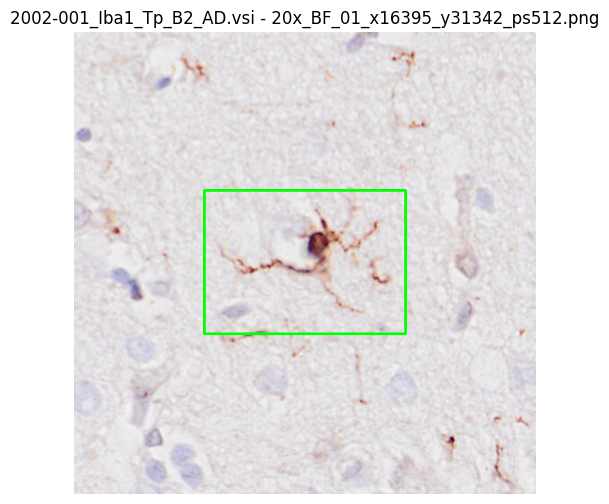

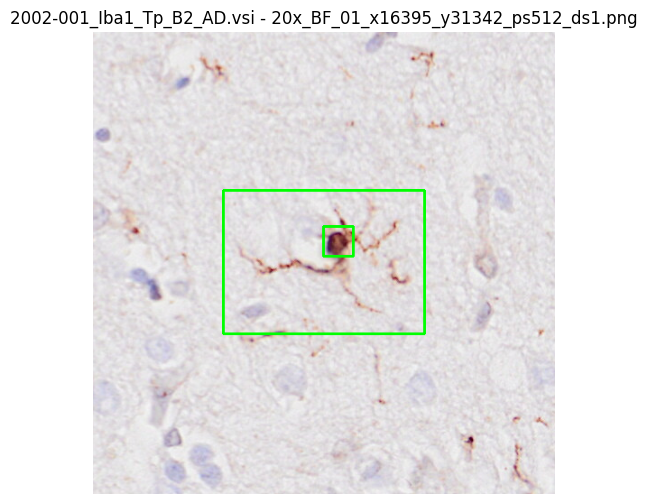

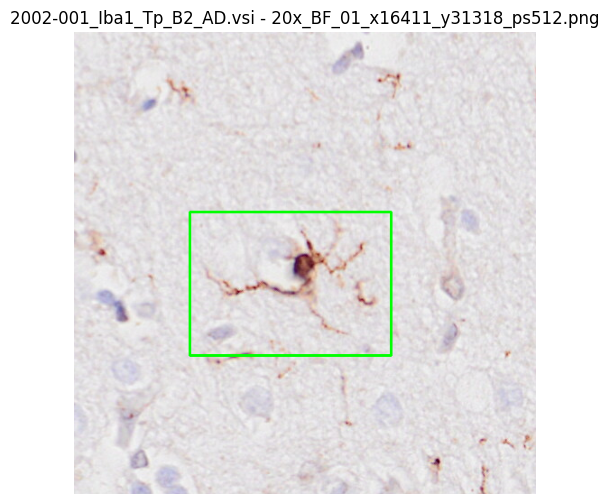

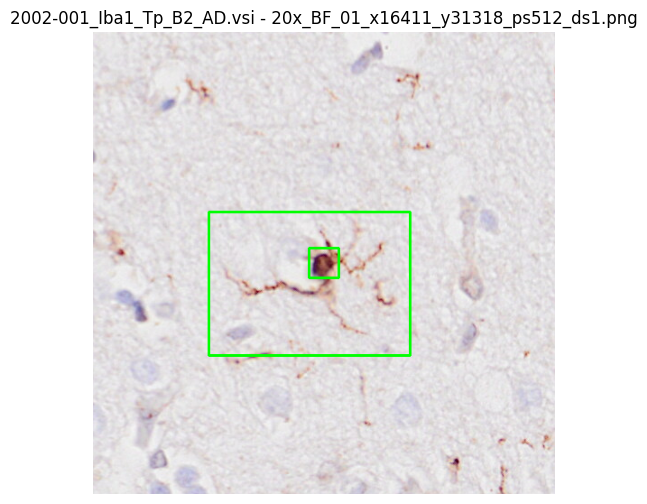

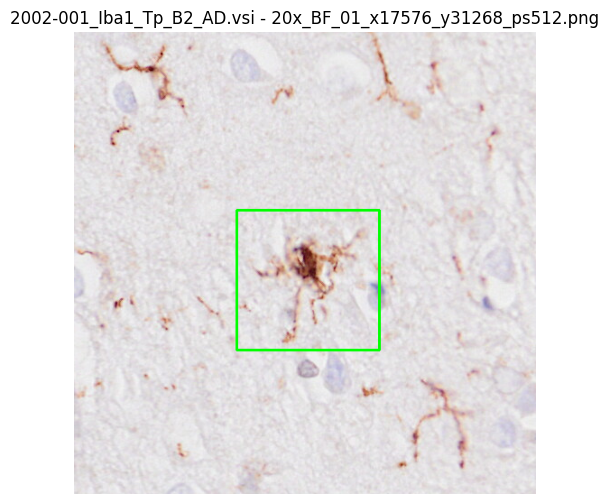

In [2]:
visualize_yolo_dataset(
    dataset_dir="C:/Users/chris/Desktop/YOLO_dataset",
    split="train",
    n=5
)
